In [ ]:
# ===== CÉLULA A: setup + upload + base unificada (CUBATÃO) =====
!pip install tigramite dowhy -q

from google.colab import files
import pandas as pd, numpy as np

print("Suba os DOIS arquivos: cubatao_industrial_...parquet E meteo_cubatao_2021_2022.parquet")
up = files.upload()

nome_pol = [k for k in up if "cubatao_industrial" in k][0]
nome_met = [k for k in up if "meteo" in k][0]

pol = pd.read_parquet(nome_pol)
met = pd.read_parquet(nome_met)
pol["data"] = pd.to_datetime(pol["data"])
met["data"] = pd.to_datetime(met["data"])

# foca em V.Parisi (epicentro industrial)
vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()

# trata zeros implausiveis como faltantes
for c in ["so2","pm10","no2"]:
    if c in vp.columns:
        vp.loc[vp[c] <= 0, c] = np.nan

# junta com meteorologia
base = vp.merge(met, on="data", how="left").sort_values("data").set_index("data")

cols = ["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"]
cols = [c for c in cols if c in base.columns]
base = base[cols].asfreq("D")

print("\n=== BASE V.PARISI + METEO ===")
print("Periodo:", base.index.min().date(), "->", base.index.max().date())
print("Dias totais:", len(base))
print("Dias completos (sem NaN):", base.dropna().shape[0])
print("\nValidos por variavel:")
print(base.notna().sum().to_string())
print("\nCorrelacoes com PM10:")
print(base.corr()["pm10"].sort_values(ascending=False).round(3).to_string())


Suba os DOIS arquivos: cubatao_industrial_...parquet E meteo_cubatao_2021_2022.parquet


In [ ]:
import pandas as pd, numpy as np, glob

arq_pol = glob.glob("/content/cubatao_industrial*.parquet")
arq_met = glob.glob("/content/meteo_cubatao*.parquet")
print("Poluentes:", arq_pol)
print("Meteo:", arq_met)

pol = pd.read_parquet(arq_pol[0])
met = pd.read_parquet(arq_met[0])
pol["data"] = pd.to_datetime(pol["data"])
met["data"] = pd.to_datetime(met["data"])

vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2","pm10","no2"]:
    if c in vp.columns:
        vp.loc[vp[c] <= 0, c] = np.nan

base = vp.merge(met, on="data", how="left").sort_values("data").set_index("data")
cols = [c for c in ["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"] if c in base.columns]
base = base[cols].asfreq("D")

print("\n=== BASE V.PARISI + METEO ===")
print("Periodo:", base.index.min().date(), "->", base.index.max().date())
print("Dias totais:", len(base))
print("Dias completos (sem NaN):", base.dropna().shape[0])
print("\nValidos por variavel:")
print(base.notna().sum().to_string())
print("\nCorrelacoes com PM10:")
print(base.corr()["pm10"].sort_values(ascending=False).round(3).to_string())


Poluentes: ['/content/cubatao_industrial_20260708_120559.parquet']
Meteo: ['/content/meteo_cubatao_2021_2022.parquet']

=== BASE V.PARISI + METEO ===
Periodo: 2021-01-12 -> 2022-12-31
Dias totais: 719
Dias completos (sem NaN): 605

Validos por variavel:
so2           651
pm10          703
no2           657
temp_media    703
chuva_mm      703
vento_max     703
umidade       703
pressao       703

Correlacoes com PM10:
pm10          1.000
no2           0.459
so2           0.380
temp_media    0.197
vento_max     0.078
pressao      -0.192
chuva_mm     -0.426
umidade      -0.569


NameError: name 'base' is not defined

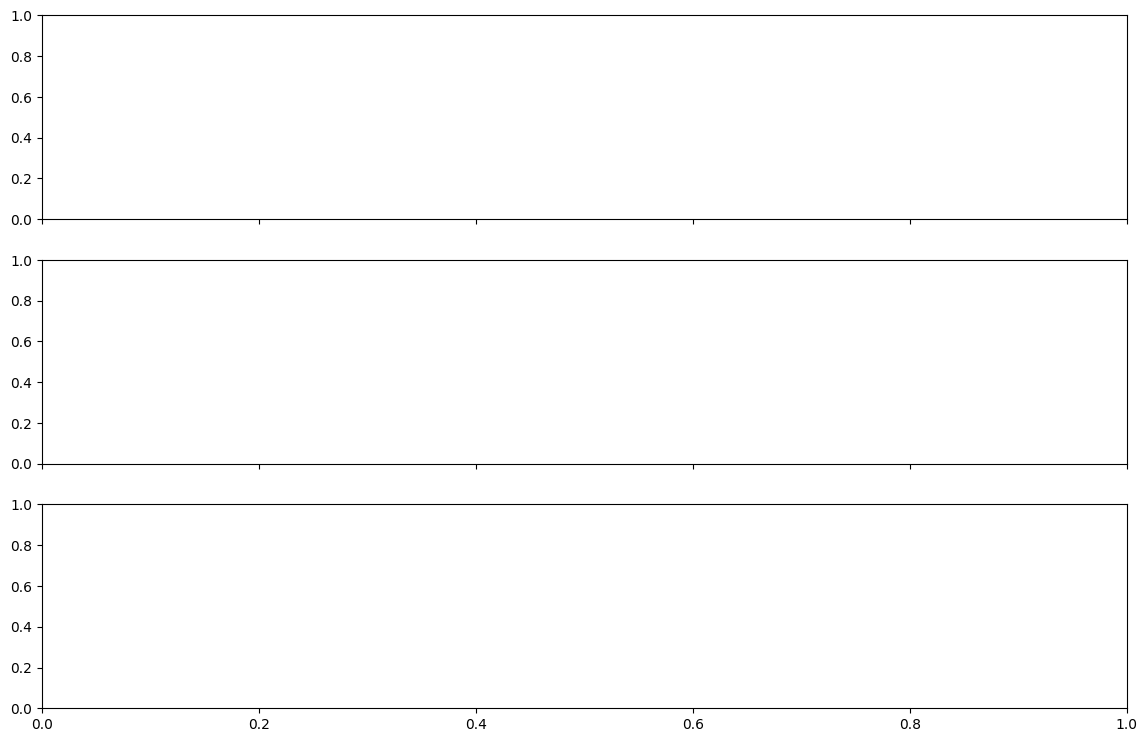

In [ ]:
import pandas as pd, numpy as np, glob
import matplotlib.pyplot as plt

arq_pol = glob.glob("/content/cubatao_industrial*.parquet")
arq_met = glob.glob("/content/meteo_cubatao*.parquet")
print("Poluentes:", arq_pol)
print("Meteo:", arq_met)

pol = pd.read_parquet(arq_pol[0])
met = pd.read_parquet(arq_met[0])
pol["data"] = pd.to_datetime(pol["data"])
met["data"] = pd.to_datetime(met["data"])

vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2","pm10","no2"]:
    if c in vp.columns:
        vp.loc[vp[c] <= 0, c] = np.nan

base = vp.merge(met, on="data", how="left").sort_values("data").set_index("data")
cols = [c for c in ["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"] if c in base.columns]
base = base[cols].asfreq("D")
print("Base montada:", base.shape, "| dias completos:", base.dropna().shape[0])

fig, ax = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
ax[0].plot(base.index, base["so2"], color="tab:orange", lw=0.8)
ax[0].set_ylabel("SO₂ (µg/m³)"); ax[0].grid(alpha=0.3)
ax[0].set_title("Cubatão-V.Parisi — SO₂ (assinatura industrial)")
ax[1].plot(base.index, base["pm10"], color="tab:brown", lw=0.8)
ax[1].set_ylabel("PM10 (µg/m³)"); ax[1].grid(alpha=0.3)
ax[1].set_title("Cubatão-V.Parisi — PM10 (material particulado)")
ax[2].plot(base.index, base["no2"], color="tab:red", lw=0.8)
ax[2].set_ylabel("NO₂ (µg/m³)"); ax[2].grid(alpha=0.3)
ax[2].set_title("Cubatão-V.Parisi — NO₂")
plt.tight_layout(); plt.show()

print("Correlacao defasada (SO2 de X dias atras vs PM10 de hoje):")
for lag in range(0, 8):
    c = base["pm10"].corr(base["so2"].shift(lag))
    print(f"  lag {lag} dia(s): {c:.3f}")


Poluentes: ['/content/cubatao_industrial_20260708_120559.parquet']
Meteo: ['/content/meteo_cubatao_2021_2022.parquet']
Base montada: (719, 8) | dias completos: 605


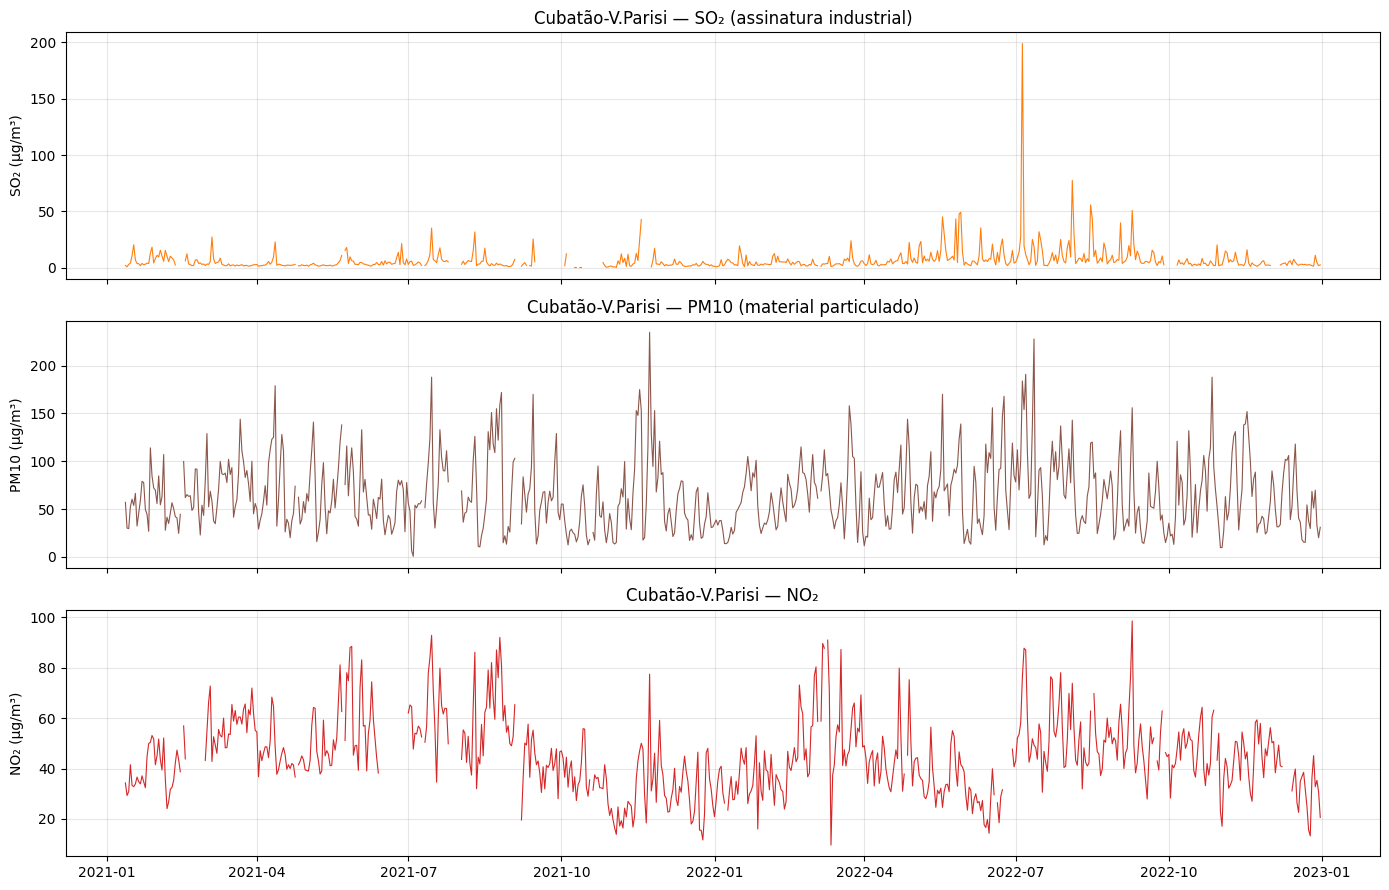

Correlacao defasada (SO2 de X dias atras vs PM10 de hoje):
  lag 0 dia(s): 0.380
  lag 1 dia(s): 0.178
  lag 2 dia(s): 0.076
  lag 3 dia(s): 0.014
  lag 4 dia(s): -0.016
  lag 5 dia(s): 0.030
  lag 6 dia(s): 0.077
  lag 7 dia(s): 0.146


In [ ]:
import pandas as pd, numpy as np, glob
import matplotlib.pyplot as plt

arq_pol = glob.glob("/content/cubatao_industrial*.parquet")
arq_met = glob.glob("/content/meteo_cubatao*.parquet")
print("Poluentes:", arq_pol)
print("Meteo:", arq_met)

pol = pd.read_parquet(arq_pol[0])
met = pd.read_parquet(arq_met[0])
pol["data"] = pd.to_datetime(pol["data"])
met["data"] = pd.to_datetime(met["data"])

vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2","pm10","no2"]:
    if c in vp.columns:
        vp.loc[vp[c] <= 0, c] = np.nan

base = vp.merge(met, on="data", how="left").sort_values("data").set_index("data")
cols = [c for c in ["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"] if c in base.columns]
base = base[cols].asfreq("D")
print("Base montada:", base.shape, "| dias completos:", base.dropna().shape[0])

fig, ax = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
ax[0].plot(base.index, base["so2"], color="tab:orange", lw=0.8)
ax[0].set_ylabel("SO₂ (µg/m³)"); ax[0].grid(alpha=0.3)
ax[0].set_title("Cubatão-V.Parisi — SO₂ (assinatura industrial)")
ax[1].plot(base.index, base["pm10"], color="tab:brown", lw=0.8)
ax[1].set_ylabel("PM10 (µg/m³)"); ax[1].grid(alpha=0.3)
ax[1].set_title("Cubatão-V.Parisi — PM10 (material particulado)")
ax[2].plot(base.index, base["no2"], color="tab:red", lw=0.8)
ax[2].set_ylabel("NO₂ (µg/m³)"); ax[2].grid(alpha=0.3)
ax[2].set_title("Cubatão-V.Parisi — NO₂")
plt.tight_layout(); plt.show()

print("Correlacao defasada (SO2 de X dias atras vs PM10 de hoje):")
for lag in range(0, 8):
    c = base["pm10"].corr(base["so2"].shift(lag))
    print(f"  lag {lag} dia(s): {c:.3f}")


In [ ]:
import pandas as pd, numpy as np, glob
from statsmodels.stats.outliers_influence import variance_inflation_factor

industrial_files = glob.glob("/content/cubatao_industrial*.parquet")
meteo_files = glob.glob("/content/meteo_cubatao*.parquet")

if not industrial_files:
    raise FileNotFoundError("No 'cubatao_industrial*.parquet' file found. Please upload the industrial data file (e.g., using `files.upload()` in a previous cell).")
if not meteo_files:
    raise FileNotFoundError("No 'meteo_cubatao*.parquet' file found. Please upload the meteorological data file (e.g., using `files.upload()` in a previous cell).")

pol = pd.read_parquet(industrial_files[0])
met = pd.read_parquet(meteo_files[0])
pol["data"] = pd.to_datetime(pol["data"]); met["data"] = pd.to_datetime(met["data"])
vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2","pm10","no2"]:
    vp.loc[vp[c] <= 0, c] = np.nan
df = vp.merge(met, on="data", how="left")
df = df[["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"]].dropna()
print("Dias completos:", len(df), "\n")

print("=== DISTRIBUICAO (SO2, PM10, NO2) ===")
print(df[["so2","pm10","no2"]].describe().round(2).to_string())

confundidores = ["no2","temp_media","chuva_mm","vento_max","umidade","pressao"]
X = df[confundidores]
vif = pd.DataFrame({
    "Variavel": X.columns,
    "VIF": [round(variance_inflation_factor(X.values, i), 2) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)
print("\n=== VIF ===")
print(vif.to_string(index=False))

print(f"\nCorrelacao SO2 vs NO2: {df['so2'].corr(df['no2']):.3f}")
p99 = df["so2"].quantile(0.99)
print(f"SO2 percentil 99: {p99:.1f} | dias acima: {(df['so2']>p99).sum()} | SO2 max: {df['so2'].max():.1f}")

IndexError: list index out of range

In [ ]:
import pandas as pd, numpy as np, glob
from statsmodels.stats.outliers_influence import variance_inflation_factor

pol = pd.read_parquet(glob.glob("/content/cubatao_industrial*.parquet")[0])
met = pd.read_parquet(glob.glob("/content/meteo_cubatao*.parquet")[0])
pol["data"] = pd.to_datetime(pol["data"]); met["data"] = pd.to_datetime(met["data"])
vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2","pm10","no2"]:
    vp.loc[vp[c] <= 0, c] = np.nan
df = vp.merge(met, on="data", how="left")
df = df[["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"]].dropna()
print("Dias completos:", len(df), "\n")

print("=== DISTRIBUICAO (SO2, PM10, NO2) ===")
print(df[["so2","pm10","no2"]].describe().round(2).to_string())

confundidores = ["no2","temp_media","chuva_mm","vento_max","umidade","pressao"]
X = df[confundidores]
vif = pd.DataFrame({
    "Variavel": X.columns,
    "VIF": [round(variance_inflation_factor(X.values, i), 2) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)
print("\n=== VIF ===")
print(vif.to_string(index=False))

print(f"\nCorrelacao SO2 vs NO2: {df['so2'].corr(df['no2']):.3f}")
p99 = df["so2"].quantile(0.99)
print(f"SO2 percentil 99: {p99:.1f} | dias acima: {(df['so2']>p99).sum()} | SO2 max: {df['so2'].max():.1f}")

Dias completos: 605 

=== DISTRIBUICAO (SO2, PM10, NO2) ===
          so2    pm10     no2
count  605.00  605.00  605.00
mean     6.87   66.21   45.34
std     11.12   36.86   15.36
min      0.13    0.44    9.65
25%      2.40   38.40   35.00
50%      3.87   59.70   43.80
75%      7.25   87.60   54.00
max    199.00  228.00   98.50

=== VIF ===
  Variavel    VIF
   pressao 292.40
   umidade 178.44
temp_media  55.10
 vento_max  13.12
       no2  10.60
  chuva_mm   1.74

Correlacao SO2 vs NO2: 0.193
SO2 percentil 99: 45.1 | dias acima: 7 | SO2 max: 199.0


In [ ]:
!pip install dowhy -q
print("dowhy pronto")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 81.6 MB/s eta 0:00:00
dowhy pronto


In [ ]:
import pandas as pd, numpy as np, glob
from dowhy import CausalModel

pol = pd.read_parquet(glob.glob("/content/cubatao_industrial*.parquet")[0])
met = pd.read_parquet(glob.glob("/content/meteo_cubatao*.parquet")[0])
pol["data"] = pd.to_datetime(pol["data"]); met["data"] = pd.to_datetime(met["data"])
vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2","pm10","no2"]:
    vp.loc[vp[c] <= 0, c] = np.nan
df = vp.merge(met, on="data", how="left")
df = df[["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"]].dropna()
print("Dias na analise:", len(df))

confundidores = ["no2","temp_media","chuva_mm","vento_max","umidade","pressao"]
model = CausalModel(data=df, treatment="so2", outcome="pm10", common_causes=confundidores)
estimando = model.identify_effect(proceed_when_unidentifiable=True)
estimativa = model.estimate_effect(estimando, method_name="backdoor.linear_regression")
print("\n=== EFEITO CAUSAL SO2 -> PM10 ===")
print("Efeito:", round(estimativa.value, 4))

print("\n[1] Causa comum aleatoria (deve MANTER):")
print(model.refute_estimate(estimando, estimativa, method_name="random_common_cause"))

print("\n[2] Placebo (deve CAIR pra ~0):")
print(model.refute_estimate(estimando, estimativa, method_name="placebo_treatment_refuter", placebo_type="permute"))

print("\n[3] Subconjunto 80% (deve MANTER):")
print(model.refute_estimate(estimando, estimativa, method_name="data_subset_refuter", subset_fraction=0.8))

Dias na analise: 605

=== EFEITO CAUSAL SO2 -> PM10 ===
Efeito: 0.4704

[1] Causa comum aleatoria (deve MANTER):
Refute: Add a random common cause
Estimated effect:0.4703748197845812
New effect:0.470369710892269
p value:0.88


[2] Placebo (deve CAIR pra ~0):
Refute: Use a Placebo Treatment
Estimated effect:0.4703748197845812
New effect:0.007897462951714403
p value:0.8999999999999999


[3] Subconjunto 80% (deve MANTER):
Refute: Use a subset of data
Estimated effect:0.4703748197845812
New effect:0.48592961002416035
p value:0.9199999999999999



In [ ]:
import pandas as pd, numpy as np, glob
import statsmodels.formula.api as smf

pol = pd.read_parquet(glob.glob("/content/cubatao_industrial*.parquet")[0])
met = pd.read_parquet(glob.glob("/content/meteo_cubatao*.parquet")[0])
pol["data"] = pd.to_datetime(pol["data"]); met["data"] = pd.to_datetime(met["data"])
vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2","pm10","no2"]:
    vp.loc[vp[c] <= 0, c] = np.nan
df = vp.merge(met, on="data", how="left")
df = df[["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"]].dropna()

# regressao com intervalo de confiança
modelo = smf.ols("pm10 ~ so2 + no2 + temp_media + chuva_mm + vento_max + umidade + pressao", data=df).fit()

print("=== EFEITO DE SO2 SOBRE PM10 (controlando confundidores) ===")
coef = modelo.params["so2"]
ic = modelo.conf_int().loc["so2"]
p = modelo.pvalues["so2"]
print(f"Efeito estimado : {coef:.4f} ug/m3 de PM10 por ug/m3 de SO2")
print(f"Intervalo 95%   : [{ic[0]:.4f} , {ic[1]:.4f}]")
print(f"p-valor         : {p:.2e}")
print(f"\nR2 do modelo    : {modelo.rsquared:.3f}")
print(f"N (dias)        : {int(modelo.nobs)}")

=== EFEITO DE SO2 SOBRE PM10 (controlando confundidores) ===
Efeito estimado : 0.4704 ug/m3 de PM10 por ug/m3 de SO2
Intervalo 95%   : [0.2594 , 0.6814]
p-valor         : 1.41e-05

R2 do modelo    : 0.510
N (dias)        : 605


In [1]:
import pandas as pd, numpy as np, glob
import statsmodels.formula.api as smf

pol = pd.read_parquet(glob.glob("/content/cubatao_industrial*.parquet")[0])
met = pd.read_parquet(glob.glob("/content/meteo_cubatao*.parquet")[0])
pol["data"] = pd.to_datetime(pol["data"]); met["data"] = pd.to_datetime(met["data"])
vp = pol[pol["estacao"] == "Cubatão-V.Parisi"].copy()
for c in ["so2","pm10","no2"]:
    vp.loc[vp[c] <= 0, c] = np.nan
df = vp.merge(met, on="data", how="left")
df = df[["so2","pm10","no2","temp_media","chuva_mm","vento_max","umidade","pressao"]].dropna()

def efeito(formula, nome):
    m = smf.ols(formula, data=df).fit()
    coef = m.params["so2"]; ic = m.conf_int().loc["so2"]; p = m.pvalues["so2"]
    print(f"{nome}")
    print(f"   efeito SO2: {coef:.4f} | IC95%: [{ic[0]:.4f}, {ic[1]:.4f}] | p: {p:.2e}\n")

print("=== ANALISE DE SENSIBILIDADE (efeito do SO2 deve se manter) ===\n")
efeito("pm10 ~ so2 + no2 + temp_media + chuva_mm + vento_max + umidade + pressao", "[1] Modelo completo (referencia)")
efeito("pm10 ~ so2 + temp_media + chuva_mm + vento_max + umidade + pressao", "[2] Sem NO2")
efeito("pm10 ~ so2 + no2 + temp_media + chuva_mm", "[3] Clima reduzido (temp + chuva)")
efeito("pm10 ~ so2", "[4] So SO2 (sem controle nenhum)")

=== ANALISE DE SENSIBILIDADE (efeito do SO2 deve se manter) ===

[1] Modelo completo (referencia)
   efeito SO2: 0.4704 | IC95%: [0.2594, 0.6814] | p: 1.41e-05

[2] Sem NO2
   efeito SO2: 0.6267 | IC95%: [0.4007, 0.8528] | p: 7.55e-08

[3] Clima reduzido (temp + chuva)
   efeito SO2: 0.9242 | IC95%: [0.7166, 1.1319] | p: 2.29e-17

[4] So SO2 (sem controle nenhum)
   efeito SO2: 1.2556 | IC95%: [1.0102, 1.5009] | p: 4.47e-22

